In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

df = pd.read_csv("/content/credit_card_fraud_10k.csv")

print(df.head())


   transaction_id  amount  transaction_hour merchant_category  \
0               1   84.47                22       Electronics   
1               2  541.82                 3            Travel   
2               3  237.01                17           Grocery   
3               4  164.33                 4           Grocery   
4               5   30.53                15              Food   

   foreign_transaction  location_mismatch  device_trust_score  \
0                    0                  0                  66   
1                    1                  0                  87   
2                    0                  0                  49   
3                    0                  1                  72   
4                    0                  0                  79   

   velocity_last_24h  cardholder_age  is_fraud  
0                  3              40         0  
1                  1              64         0  
2                  1              61         0  
3                  3  

In [ ]:
print("Missing values:", df.isnull().sum().sum())


Missing values: 0


In [ ]:
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]


In [ ]:
X = pd.get_dummies(X, drop_first=True)


In [ ]:
X = X.fillna(X.median(numeric_only=True))



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(
    X_train, y_train
)
print("\nAfter SMOTE:")
print(y_train.value_counts())



After SMOTE:
is_fraud
0    7879
1    7879
Name: count, dtype: int64


In [ ]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)


In [ ]:
model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
prob = model.predict_proba(X_test)[:, 1]


In [ ]:
print("\nROC-AUC:", roc_auc_score(y_test, prob))



ROC-AUC: 0.982605752961083


In [ ]:
threshold = 0.3

pred = (prob >= threshold).astype(int)


In [ ]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))



Confusion Matrix:
[[1864  106]
 [   4   26]]


              precision    recall  f1-score   support

           0       1.00      0.95      0.97      1970
           1       0.20      0.87      0.32        30

    accuracy                           0.94      2000
   macro avg       0.60      0.91      0.65      2000
weighted avg       0.99      0.94      0.96      2000



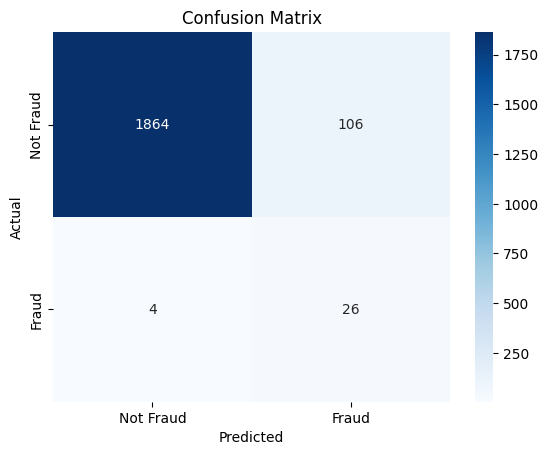

In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Fraud', 'Fraud'],
    yticklabels=['Not Fraud', 'Fraud']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop 10 Important Features:")
print(importance.head(10))


Top 10 Important Features:
device_trust_score               0.250185
transaction_hour                 0.199814
velocity_last_24h                0.100937
foreign_transaction              0.080104
location_mismatch                0.079742
merchant_category_Grocery        0.058040
merchant_category_Food           0.055441
merchant_category_Travel         0.054611
merchant_category_Electronics    0.046490
transaction_id                   0.027919
dtype: float32


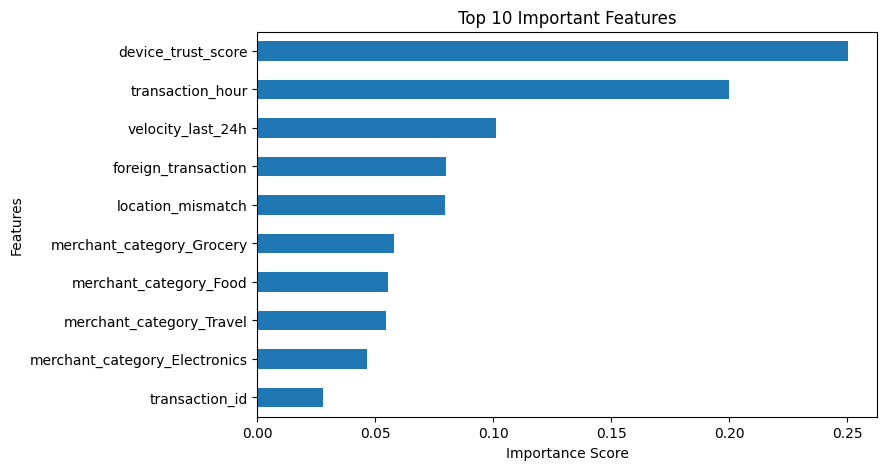

In [16]:
importance.head(10).sort_values().plot(
    kind='barh',
    figsize=(8, 5)
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Important Features")

plt.show()